# PowerTrack Client SDK — Demonstration Notebook

This Jupyter Notebook demonstrates the capabilities of the **PowerTrack Python Client Library** to interact programmatically with the Flask REST Web Service. 

PowerTrack is a workout tracker and training analytics platform that provides database storage, user CRUD management, exercise cataloging, performance logging, and aggregated metrics.

### Features Demonstrated:
1. **Client Initialization & Connection Check**: Reaching the backend API.
2. **User Profiles Management (CRUD)**: Querying and mutating user profiles.
3. **Training Plans & Workout Days (Active Record)**: Navigating models without direct resource sub-client calls.
4. **Exercise Catalog & Scheduling**: Populating catalog and planning day templates.
5. **Performance Logging (6 Weeks)**: Simulating progressive overload logging with physical pain flags.
6. **Aggregated Analytics & Reports**: Querying volume statistics, RPE averages, muscle balance, and personal records.
7. **Data Visualisation**: Displaying Matplotlib charts inline for analysis.
8. **Cascade Database Cleanup**: Ensuring database remains clean after execution.

---
## Prerequisites

1. **Flask Backend Server**: Ensure the backend server is running in the background:
   ```bash
   cd backend
   uv run python -m app.main
   ```
2. **Client Wheel Package**: Ensure the client wheel package has been built:
   ```bash
   cd client
   uv build
   ```
3. **Notebook Environment**: Make sure you have run `uv sync` in the `demo/` directory so the built `.whl` is installed in this kernel environment.

---
## 1. Initialization and Connection Check

First, we import the core classes `PowerTrackClient` and `PowerTrackPlots` and instantiate the client pointing to our backend REST API (`http://127.0.0.1:8000`). We run `ping()` to check if the server is online.

In [1]:
from client import PowerTrackClient, PowerTrackPlots
from client.exceptions import PowerTrackConflictError, PowerTrackNotFoundError, PowerTrackValidationError

# Instantiate the client
client = PowerTrackClient("http://127.0.0.1:8000")

# Verify backend connectivity
if client.ping():
    print("Backend server is online and reachable!")
else:
    print("Backend server is OFFLINE. Please check backend server setup.")

Backend server is online and reachable!


---
## 2. User Management (CRUD & Exceptions)

We test creating two users, listing all users, and catching expected errors like creating duplicate usernames or fetching users that do not exist (raising mapped HTTP exceptions).

In [2]:
print("--- Creating Users ---")
# Clean up existing users from previous runs if they exist
for u in client.users.list():
    if u.username in ('marco_nb', 'sara_nb'):
        client.users.delete(u.id)

user_marco = client.users.create(username="marco_nb")
user_sara = client.users.create(username="sara_nb")
print(f"Created: {user_marco}")
print(f"Created: {user_sara}")

print("\n--- Active Users List ---")
users = client.users.list()
for u in users:
    print(f"  • {u}")

print("\n--- Error Handling: Duplicate Username ---")
try:
    client.users.create(username="marco_nb")
except (PowerTrackConflictError, PowerTrackValidationError) as e:
    print(f"Expected exception caught (Conflict 409): {e.message}")

print("\n--- Error Handling: User Not Found ---")
try:
    client.users.get(9999)
except PowerTrackNotFoundError as e:
    print(f"Expected exception caught (Not Found 404): Resource not found.")

--- Creating Users ---
Created: User(id=1, username='marco_nb')
Created: User(id=2, username='sara_nb')

--- Active Users List ---
  • User(id=1, username='marco_nb')
  • User(id=2, username='sara_nb')

--- Error Handling: Duplicate Username ---
Expected exception caught (Conflict 409): {
  "errors": {
    "username": [
      "username already taken"
    ]
  }
}


--- Error Handling: User Not Found ---
Expected exception caught (Not Found 404): Resource not found.


---
## 3. Training Plan & Workout Days (Active Record Navigation)

Here, we create a 6-week training plan. Instead of calling `client.plans.get_by_user()`, we leverage the **Active Record Pattern** directly: the `User` object (`user_marco`) exposes `get_plans()` because it has a reference to the active client. 

We then add workout day templates inside the plan and retrieve them using `plan.get_days()`.

In [3]:
print("--- Creating a 6-week Plan ---")
plan = client.plans.create(user_id=user_marco.id, name="Hypertrophy Block A", total_weeks=6)
print(f"Created Plan: {plan}")

print("\n--- Active Record: Traversing from User to Plans ---")
marco_plans = user_marco.get_plans()
print(f"Plans retrieved directly from user object: {marco_plans}")

print("\n--- Scheduling Workout Days ---")
day_push = client.workout_days.create(plan_id=plan.id, name="Day A - Push", day_order=1)
day_pull = client.workout_days.create(plan_id=plan.id, name="Day B - Pull", day_order=2)
day_legs = client.workout_days.create(plan_id=plan.id, name="Day C - Legs", day_order=3)

print("\n--- Active Record: Traversing from Plan to Workout Days ---")
for day in plan.get_days():
    print(f"  • Day {day.day_order}: {day.name} (ID: {day.id})")

--- Creating a 6-week Plan ---
Created Plan: TrainingPlan(id=1, user_id=1, name='Hypertrophy Block A', total_weeks=6, start_date='2026-05-31T20:37:41.309904')

--- Active Record: Traversing from User to Plans ---
Plans retrieved directly from user object: [TrainingPlan(id=1, user_id=1, name='Hypertrophy Block A', total_weeks=6, start_date='2026-05-31T20:37:41.309904')]

--- Scheduling Workout Days ---

--- Active Record: Traversing from Plan to Workout Days ---
  • Day 1: Day A - Push (ID: 1)
  • Day 2: Day B - Pull (ID: 2)
  • Day 3: Day C - Legs (ID: 3)


---
## 4. Exercise Catalog & Scheduling

We register a set of template exercises in the database catalog, query the catalog using filter parameters, and schedule them into our workout day templates.

In [4]:
print("--- Registering Exercises in Global Catalog ---")
ex_bench = client.exercises.create(name="Bench Press", mechanics_type="Multi-joint", target_muscle="Chest")
ex_squat = client.exercises.create(name="Squat", mechanics_type="Multi-joint", target_muscle="Legs")
ex_extension = client.exercises.create(name="Leg Extensions", mechanics_type="Isolation", target_muscle="Legs")
print(f"  Added: {ex_bench}")
print(f"  Added: {ex_squat}")
print(f"  Added: {ex_extension}")

print("\n--- Querying Exercises with Filters (target_muscle='Legs') ---")
legs_catalog = client.exercises.list(target_muscle="Legs")
for ex in legs_catalog:
    print(f"  • {ex}")

print("\n--- Scheduling Exercises on Workout Days ---")
# Schedule Bench Press on Push Day
pe_bench = client.plan_exercises.create(
    workout_day_id=day_push.id, exercise_id=ex_bench.id,
    exercise_order=1, notes="Warm up well"
)
# Schedule Squats and Extensions on Legs Day
pe_squat = client.plan_exercises.create(
    workout_day_id=day_legs.id, exercise_id=ex_squat.id,
    exercise_order=1, notes="Keep core tight"
)
pe_ext = client.plan_exercises.create(
    workout_day_id=day_legs.id, exercise_id=ex_extension.id,
    exercise_order=2, notes="Squeeze at the top"
)

print("\n--- Active Record: Traversing Day A Exercises ---")
for pe in day_push.get_exercises():
    print(f"  Scheduled: {pe.id} - Order {pe.exercise_order} (Notes: {pe.notes})")

--- Registering Exercises in Global Catalog ---
  Added: Exercise(id=1, name='Bench Press', mechanics_type='Multi-joint', target_muscle='Chest')
  Added: Exercise(id=2, name='Squat', mechanics_type='Multi-joint', target_muscle='Legs')
  Added: Exercise(id=3, name='Leg Extensions', mechanics_type='Isolation', target_muscle='Legs')

--- Querying Exercises with Filters (target_muscle='Legs') ---
  • Exercise(id=2, name='Squat', mechanics_type='Multi-joint', target_muscle='Legs')
  • Exercise(id=3, name='Leg Extensions', mechanics_type='Isolation', target_muscle='Legs')

--- Scheduling Exercises on Workout Days ---

--- Active Record: Traversing Day A Exercises ---
  Scheduled: 1 - Order 1 (Notes: Warm up well)


---
## 5. Performance Logging (6 Weeks)

We log workout performances for each of the 6 weeks. To make it realistic, we implement progressive overload (weekly load increment) and inject a **pain/discomfort flag** on Week 4 for Leg Extensions.

In [5]:
print("--- Logging 6 Weeks of Workouts (Progressive Overload) ---")

for week in range(1, 7):
    # Log Bench Press (increasing weight from 60kg to 72.5kg)
    client.session_logs.create(
        plan_exercise_id=pe_bench.id, week_number=week,
        sets=4, reps=8, weight=60.0 + 2.5 * (week - 1),
        rpe=6 + int(week / 2), pain_discomfort=False
    )

    # Log Squats (increasing weight from 80kg to 105kg)
    client.session_logs.create(
        plan_exercise_id=pe_squat.id, week_number=week,
        sets=4, reps=6, weight=80.0 + 5.0 * (week - 1),
        rpe=7 + int(week / 2), pain_discomfort=False
    )

    # Log Leg Extensions (Knee discomfort in week 4)
    has_pain = (week == 4)
    feedback = "Felt sharp pain in the patellar tendon during last set" if has_pain else None
    client.session_logs.create(
        plan_exercise_id=pe_ext.id, week_number=week,
        sets=3, reps=15, weight=30.0 + 2.0 * (week - 1),
        rpe=5 + int(week / 2), pain_discomfort=has_pain, user_feedback=feedback
    )

print("Performance logging completed!")

print("\n--- Active Record: Traversing Bench Press Logs ---")
for log in pe_bench.get_logs():
    print(f"  Week {log.week_number}: {log.sets}x{log.reps} @ {log.weight}kg (RPE {log.rpe})")

--- Logging 6 Weeks of Workouts (Progressive Overload) ---
Performance logging completed!

--- Active Record: Traversing Bench Press Logs ---
  Week 1: 4x8 @ 60.0kg (RPE 6)
  Week 2: 4x8 @ 62.5kg (RPE 7)
  Week 3: 4x8 @ 65.0kg (RPE 7)
  Week 4: 4x8 @ 67.5kg (RPE 8)
  Week 5: 4x8 @ 70.0kg (RPE 8)
  Week 6: 4x8 @ 72.5kg (RPE 9)


---
## 6. Training Statistics & Reports

We query the analytics endpoints on the server. The data is parsed into structured report classes containing week-by-week total workloads, multi-joint splits, average RPEs, and personal best milestones.

In [6]:
print("--- Plan Workload Volume ---")
vol = plan.get_total_volume()
for w in vol.data:
    print(f"  Week {w.week_number}: Total Volume = {w.total_volume:,.0f} kg")

print("\n--- Plan Average RPE trend ---")
rpe = plan.get_avg_rpe()
for w in rpe.data:
    print(f"  Week {w.week_number}: Avg RPE = {w.avg_rpe:.1f} ({w.sessions_logged} logs)")

print("\n--- Muscle Balance Share ---")
balance = plan.get_muscle_balance()
for entry in balance.data:
    bar = "█" * int(entry.percentage / 2)
    print(f"  {entry.target_muscle:12s} {bar} {entry.percentage:.1f}%")

print("\n--- Pain/Discomfort Flag Report ---")
pain = plan.get_pain_report()
print(f"  Total pain flags reported: {pain.total_pain_flags}")
for log in pain.data:
    print(f"Week {log.week_number} - {log.exercise} (RPE {log.rpe}): {log.user_feedback}")

print("\n--- Personal Best Tracking ---")
pb_squat = ex_squat.get_personal_best(user_marco.id)
print(f" Squat PR: {pb_squat["max_weight"]} kg x {pb_squat["reps_at_max"]} reps in Week {pb_squat["week_achieved"]}")

--- Plan Workload Volume ---
  Week 1: Total Volume = 5,190 kg
  Week 2: Total Volume = 5,480 kg
  Week 3: Total Volume = 5,770 kg
  Week 4: Total Volume = 6,060 kg
  Week 5: Total Volume = 6,350 kg
  Week 6: Total Volume = 6,640 kg

--- Plan Average RPE trend ---
  Week 1: Avg RPE = 6.0 (3 logs)
  Week 2: Avg RPE = 7.0 (3 logs)
  Week 3: Avg RPE = 7.0 (3 logs)
  Week 4: Avg RPE = 8.0 (3 logs)
  Week 5: Avg RPE = 8.0 (3 logs)
  Week 6: Avg RPE = 9.0 (3 logs)

--- Muscle Balance Share ---
  Legs         ████████████████████████████████ 64.2%
  Chest        █████████████████ 35.8%

--- Pain/Discomfort Flag Report ---
  Total pain flags reported: 1
Week 4 - Leg Extensions (RPE 7): Felt sharp pain in the patellar tendon during last set

--- Personal Best Tracking ---
 Squat PR: 105.0 kg x 6 reps in Week 6


---
## 7. Data Visualisation (Inline Matplotlib Rendering)

Using `%matplotlib inline`, we can render the training analytics directly in the cells. We instantiate `PowerTrackPlots` passing the client.

--- 1. Volume & RPE Progression (Squat) ---


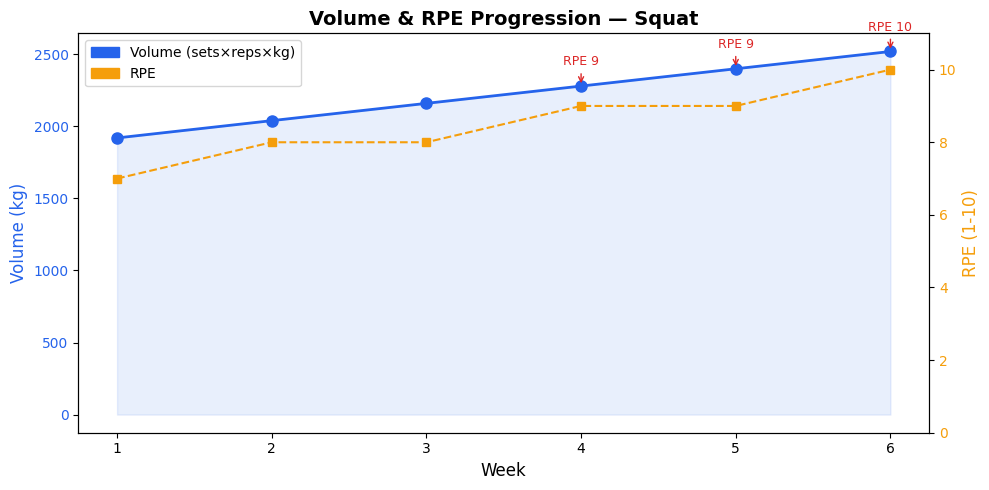


--- 2. Total Weekly Plan Volume ---


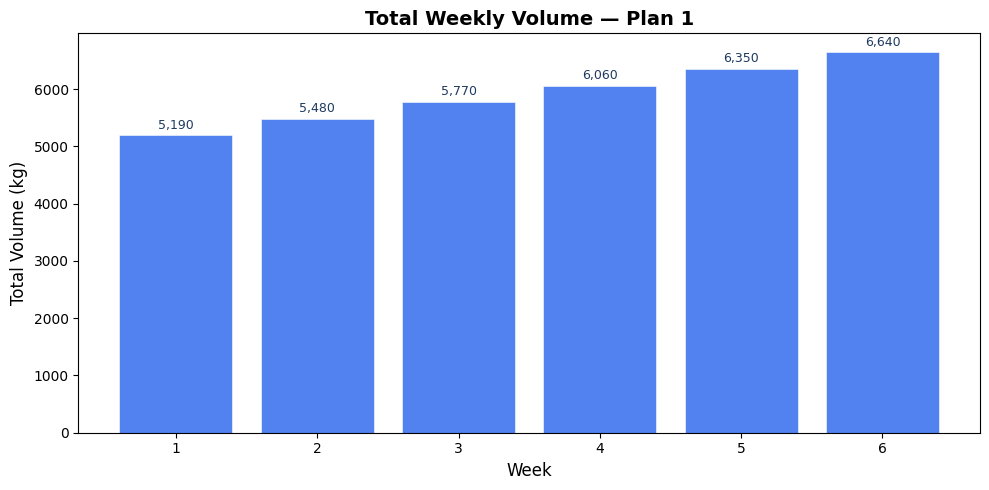


--- 3. Multi-Joint compound vs Total Volume ---


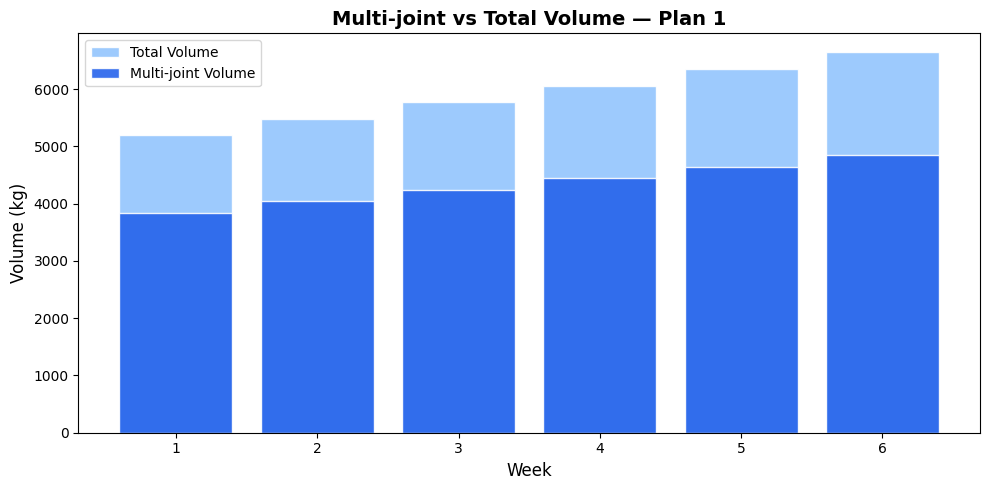


--- 4. Weekly Average RPE Trend ---


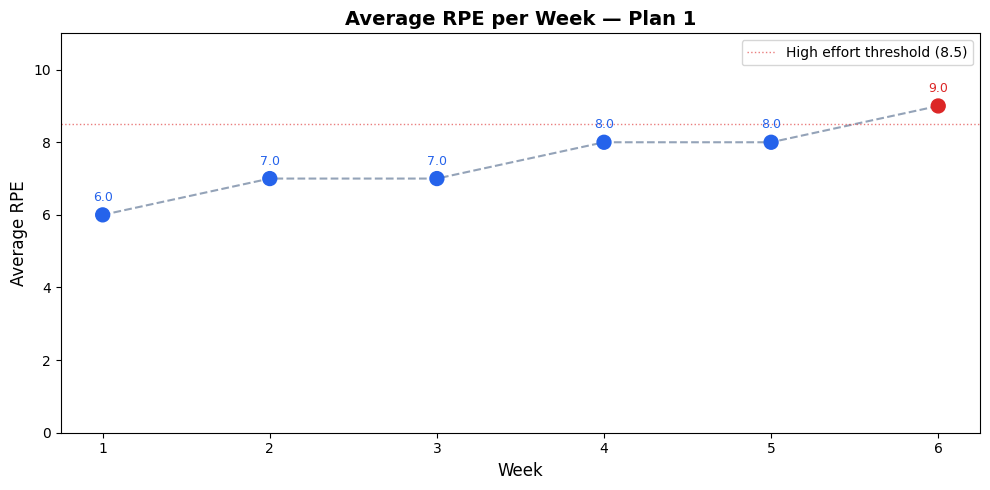


--- 5. Volume Distribution Share ---


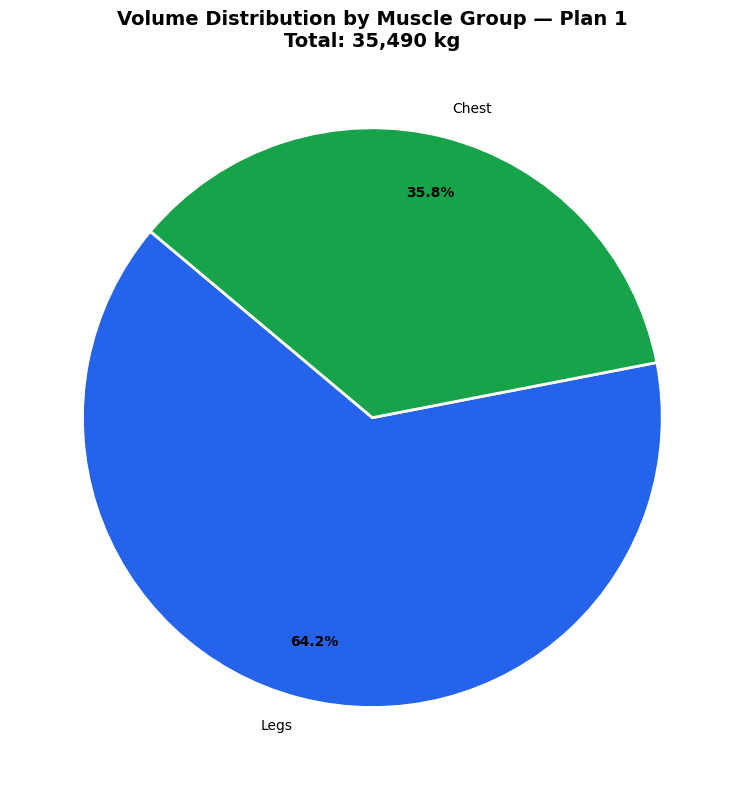


--- 6. Discomfort timeline ---


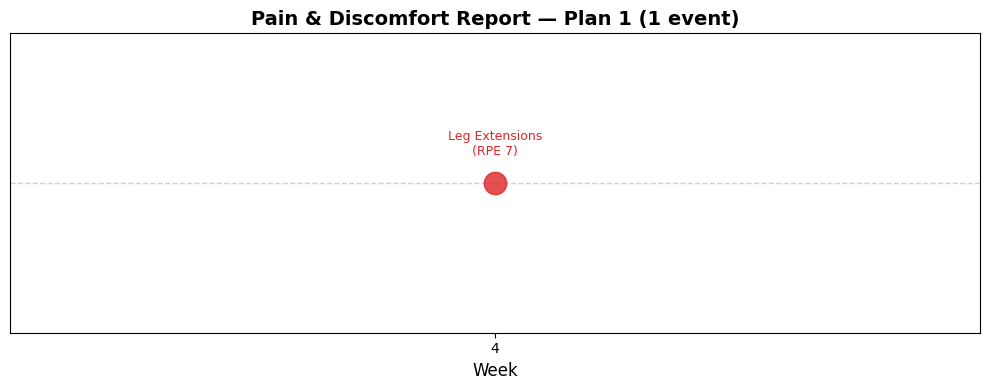

In [7]:
# Configure matplotlib inline display
%matplotlib inline

# Initialize the plotting service
plots = PowerTrackPlots(client)

print("--- 1. Volume & RPE Progression (Squat) ---")
plots.plot_volume_progression(pe_squat.id, show=True)

print("\n--- 2. Total Weekly Plan Volume ---")
plots.plot_total_volume(plan.id, show=True)

print("\n--- 3. Multi-Joint compound vs Total Volume ---")
plots.plot_multijoint_vs_total(plan.id, show=True)

print("\n--- 4. Weekly Average RPE Trend ---")
plots.plot_rpe_trend(plan.id, show=True)

print("\n--- 5. Volume Distribution Share ---")
plots.plot_muscle_balance(plan.id, show=True)

print("\n--- 6. Discomfort timeline ---")
plots.plot_pain_report(plan.id, show=True)

---
## 8. Cascading Database Cleanup

We delete the users and catalog exercises. The database engine cascades deletions through foreign keys (deleting user logs, workout days, etc.) to keep the backend clean.

In [8]:
print("--- Performing Cleanup ---")
# Cascade delete user data
res1 = client.users.delete(user_marco.id)
res2 = client.users.delete(user_sara.id)
print(f"  Deleted {user_marco.username}: {res1}")
print(f"  Deleted {user_sara.username}: {res2}")

# Delete catalog items
client.exercises.delete(ex_bench.id)
client.exercises.delete(ex_squat.id)
client.exercises.delete(ex_extension.id)

print("\nAll demo entries successfully cleared. DB is clean!")

--- Performing Cleanup ---
  Deleted marco_nb: {'message': 'User 1 deleted'}
  Deleted sara_nb: {'message': 'User 2 deleted'}

All demo entries successfully cleared. DB is clean!
